# Mars InSight HP3 — Data Exploration

**Read this notebook first**, before `PINN-Setup.ipynb`.

This notebook loads the raw temperature data from NASA's InSight lander and builds intuition for the physics before we try to model it with a PINN. Two datasets are compared:

- **Diurnal** (one Martian sol): surface temperature swings ~100 K, but by the mole depth (~9 cm) only ~7 K remains — the soil acts as a low-pass filter.
- **Annual** (~600 sols): seasonal temperature waves that penetrate deeper, with the mole signal lagging the surface by ~21 sols.

Key things to notice:
1. The **amplitude ratio** between surface and mole tells you how quickly the signal decays with depth — this is controlled by the thermal diffusivity $\kappa$.
2. The **phase lag** tells you how long the thermal wave takes to propagate down — also controlled by $\kappa$.
3. Both observations constrain the same parameter, which is what the PINN will eventually try to recover.

> **Data required:** Download the Excel files from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

Mole (TEM-A 1202): 5550 points, range 222.5 – 229.2 K
Surface (RAD 511):  552 points, range 187.3 – 294.1 K

Mole H/K annual:    565 points, range 212.7 – 225.5 K
TEM-A snapshots:    7 points
Surface RAD annual: 565 points, range 215.5 – 228.8 K


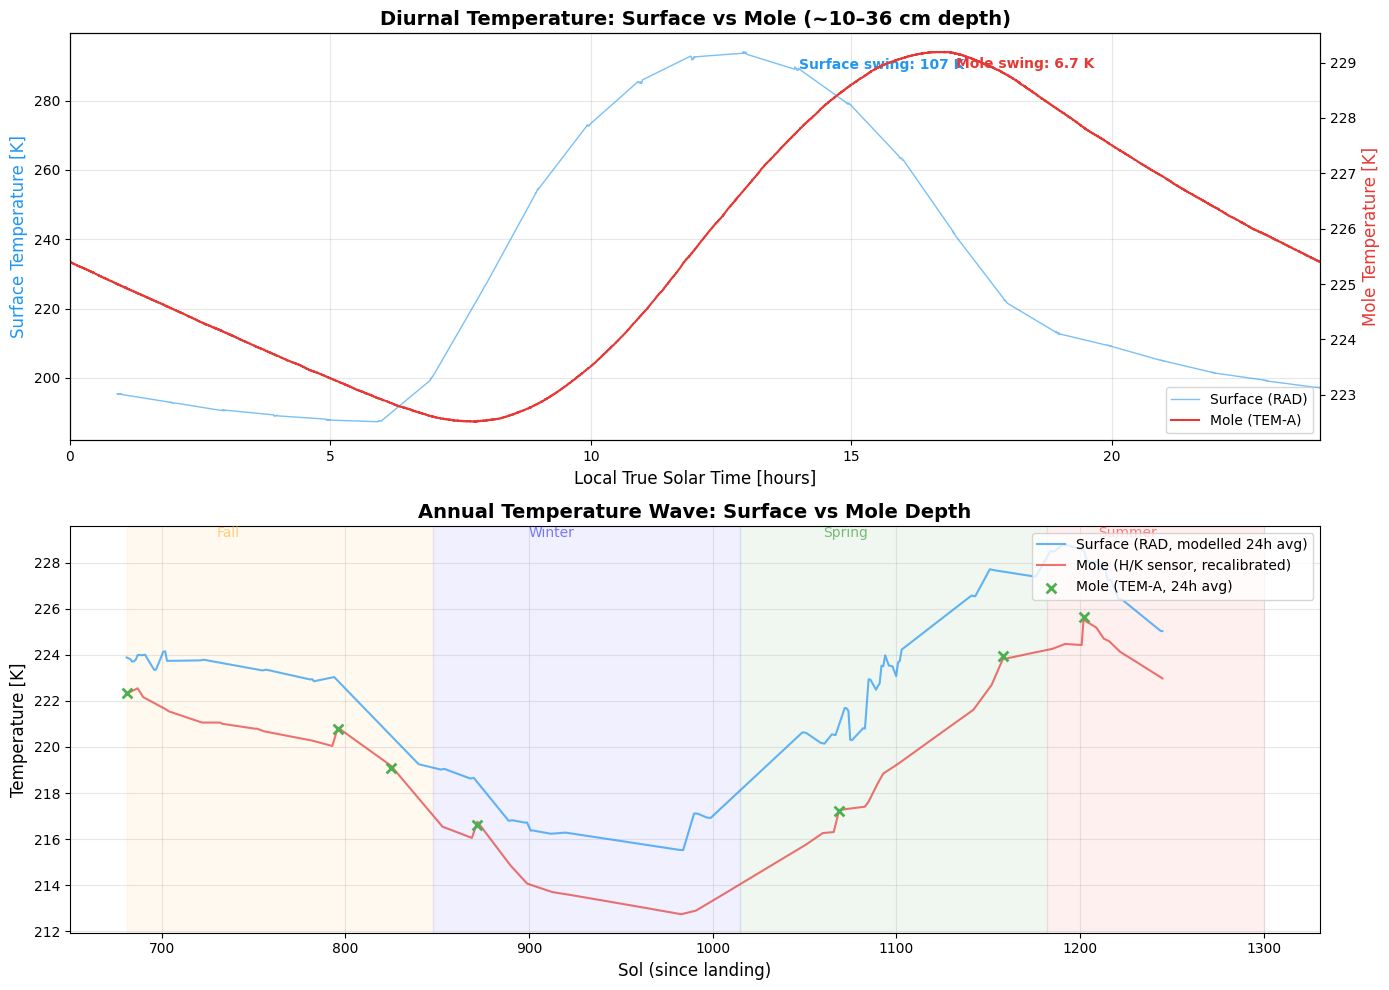


QUESTIONS TO ANSWER FROM YOUR PLOTS

1. DIURNAL AMPLITUDE RATIO:
   Surface amplitude: 106.8 K
   Mole amplitude:    6.7 K
   Ratio (mole/surface): 0.063
   → The signal is attenuated by a factor of ~16x

2. PHASE LAG (diurnal):
   Surface peak at ~12.9 h LTST
   Mole peak at    ~16.7 h LTST
   Phase lag: ~3.8 hours

3. ANNUAL SIGNAL:
   Surface range: 215.5 – 228.8 K (Δ = 13.3 K)
   Mole range:    212.7 – 225.5 K (Δ = 12.8 K)
   → Surface leads (peaks first), mole follows with ~21 sol phase lag

4. YOUR PINN WILL NEED:
   - Inputs:  (x, t)  where x = depth [0, ~0.5 m], t = time
   - Output:  T(x, t) in Kelvin
   - BC at x=0: surface temperature (blue curves)
   - Data at x ≈ 0.10–0.36 m: mole observations (red curves)
   - PDE: ∂T/∂t = κ · ∂²T/∂x²


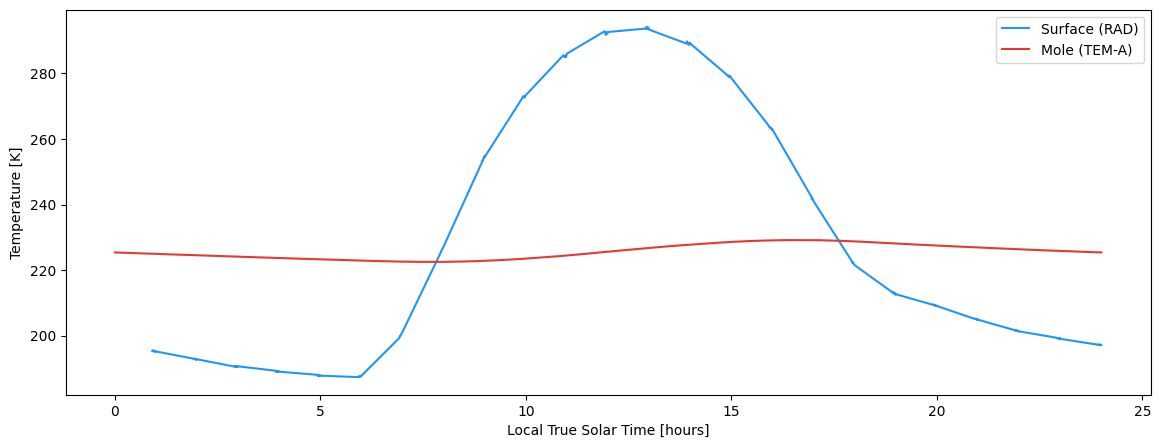

In [3]:
# ============================================================
# Mars InSight HP3 Temperature Data - First Look
# ============================================================
# Make sure the two Excel files are in the same directory as this notebook:
#   - Mars_Soil_Temperatures_and_Thermal_Properties_from_Diurnal_Wave_data.xlsx
#   - Mars_Soil_Temperatures_and_Thermal_Properties_from_Annual_Wave_Data.xlsx
#
# pip install openpyxl matplotlib numpy

import openpyxl
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# PART 1: Load Diurnal Data
# ============================================================
# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    'Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass

# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

print(f"Mole (TEM-A 1202): {len(ltst_mole)} points, range {min(temp_mole):.1f} – {max(temp_mole):.1f} K")
print(f"Surface (RAD 511):  {len(ltst_surf)} points, range {min(temp_surf):.1f} – {max(temp_surf):.1f} K")

# ============================================================
# PART 2: Load Annual Data
# ============================================================
wb_annual = openpyxl.load_workbook(
    'Mars Soil Temperatures and Thermal Properties from Annual Wave Data.xlsx',
    data_only=True
)

ws_ann = wb_annual['2nd year Temp (Fig. 2)']

sol_hk, temp_hk = [], []         # H/K mole sensor (daily readings over ~600 sols)
sol_tema, temp_tema = [], []      # TEM-A mole sensor (7 individual 48h measurements)
sol_rad_ann, temp_rad_ann = [], [] # Surface temperature (modelled 24h average)

for row in ws_ann.iter_rows(min_row=2, values_only=True):
    sol = row[0]
    mole_recal = row[3]   # Column D: Mole Temp recalibrated (H/K sensor)
    tema_val   = row[8]   # Column I: TEM-A 24h average
    rad_model  = row[10]  # Column K: RAD modelled 24h average

    if sol is None:
        continue
    try:
        s = float(sol)
    except (ValueError, TypeError):
        continue

    if mole_recal is not None:
        try:
            sol_hk.append(s)
            temp_hk.append(float(mole_recal))
        except (ValueError, TypeError):
            pass

    if tema_val is not None:
        try:
            sol_tema.append(s)
            temp_tema.append(float(tema_val))
        except (ValueError, TypeError):
            pass

    if rad_model is not None:
        try:
            sol_rad_ann.append(s)
            temp_rad_ann.append(float(rad_model))
        except (ValueError, TypeError):
            pass

print(f"\nMole H/K annual:    {len(sol_hk)} points, range {min(temp_hk):.1f} – {max(temp_hk):.1f} K")
print(f"TEM-A snapshots:    {len(sol_tema)} points")
print(f"Surface RAD annual: {len(sol_rad_ann)} points, range {min(temp_rad_ann):.1f} – {max(temp_rad_ann):.1f} K")

# ============================================================
# PART 3: Plot
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ----------------------------------------------------------
# Subplot 1: Diurnal — one Martian day
# ----------------------------------------------------------
# Twin axes because surface (~190-290 K) and mole (~222-229 K) 
# live on very different scales
ax1 = axes[0]
ax1_twin = ax1.twinx()

ax1.plot(ltst_surf, temp_surf, color='#2196F3', alpha=0.6, linewidth=1, 
         label='Surface (RAD)')
ax1_twin.plot(ltst_mole, temp_mole, color='#E53935', linewidth=1.5, 
              label='Mole (TEM-A)')

ax1.set_xlabel('Local True Solar Time [hours]', fontsize=12)
ax1.set_ylabel('Surface Temperature [K]', fontsize=12, color='#2196F3')
ax1_twin.set_ylabel('Mole Temperature [K]', fontsize=12, color='#E53935')
ax1.set_xlim(0, 24)
ax1.set_title('Diurnal Temperature: Surface vs Mole (~10–36 cm depth)', 
              fontsize=14, fontweight='bold')

# Annotate the amplitude difference
surf_amp = max(temp_surf) - min(temp_surf)
mole_amp = max(temp_mole) - min(temp_mole)
ax1.annotate(f'Surface swing: {surf_amp:.0f} K', xy=(14, max(temp_surf) - 5),
             fontsize=10, color='#2196F3', fontweight='bold')
ax1_twin.annotate(f'Mole swing: {mole_amp:.1f} K', xy=(17, max(temp_mole) - 0.3),
                   fontsize=10, color='#E53935', fontweight='bold')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------
# Subplot 2: Annual — seasonal cycle over ~600 sols
# ----------------------------------------------------------
ax2 = axes[1]

ax2.plot(sol_rad_ann, temp_rad_ann, color='#2196F3', linewidth=1.5, alpha=0.7,
         label='Surface (RAD, modelled 24h avg)')
ax2.plot(sol_hk, temp_hk, color='#E53935', linewidth=1.5, alpha=0.7,
         label='Mole (H/K sensor, recalibrated)')
ax2.scatter(sol_tema, temp_tema, color='#4CAF50', s=50, zorder=5, marker='x',
            linewidths=2, label='Mole (TEM-A, 24h avg)')

ax2.set_xlabel('Sol (since landing)', fontsize=12)
ax2.set_ylabel('Temperature [K]', fontsize=12)
ax2.set_title('Annual Temperature Wave: Surface vs Mole Depth', 
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3)

# Shade approximate Martian seasons
ax2.axvspan(681, 681 + 167, alpha=0.06, color='orange')
ax2.axvspan(681 + 167, 681 + 334, alpha=0.06, color='blue')
ax2.axvspan(681 + 334, 681 + 501, alpha=0.06, color='green')
ax2.axvspan(681 + 501, 1300, alpha=0.06, color='red')
y_label = max(temp_rad_ann) + 0.3
ax2.text(730, y_label, 'Fall', fontsize=10, alpha=0.5, color='orange')
ax2.text(900, y_label, 'Winter', fontsize=10, alpha=0.5, color='blue')
ax2.text(1060, y_label, 'Spring', fontsize=10, alpha=0.5, color='green')
ax2.text(1210, y_label, 'Summer', fontsize=10, alpha=0.5, color='red')

plt.tight_layout()
plt.show()

# ============================================================
# PART 4: Sanity checks — study these numbers
# ============================================================
print("\n" + "=" * 60)
print("QUESTIONS TO ANSWER FROM YOUR PLOTS")
print("=" * 60)

print(f"\n1. DIURNAL AMPLITUDE RATIO:")
print(f"   Surface amplitude: {surf_amp:.1f} K")
print(f"   Mole amplitude:    {mole_amp:.1f} K")
print(f"   Ratio (mole/surface): {mole_amp/surf_amp:.3f}")
print(f"   → The signal is attenuated by a factor of ~{surf_amp/mole_amp:.0f}x")

print(f"\n2. PHASE LAG (diurnal):")
idx_surf_peak = temp_surf.index(max(temp_surf))
idx_mole_peak = temp_mole.index(max(temp_mole))
print(f"   Surface peak at ~{ltst_surf[idx_surf_peak]:.1f} h LTST")
print(f"   Mole peak at    ~{ltst_mole[idx_mole_peak]:.1f} h LTST")
print(f"   Phase lag: ~{ltst_mole[idx_mole_peak] - ltst_surf[idx_surf_peak]:.1f} hours")

print(f"\n3. ANNUAL SIGNAL:")
print(f"   Surface range: {min(temp_rad_ann):.1f} – {max(temp_rad_ann):.1f} K "
      f"(Δ = {max(temp_rad_ann)-min(temp_rad_ann):.1f} K)")
print(f"   Mole range:    {min(temp_hk):.1f} – {max(temp_hk):.1f} K "
      f"(Δ = {max(temp_hk)-min(temp_hk):.1f} K)")
print(f"   → Surface leads (peaks first), mole follows with ~21 sol phase lag")

print(f"\n4. YOUR PINN WILL NEED:")
print(f"   - Inputs:  (x, t)  where x = depth [0, ~0.5 m], t = time")
print(f"   - Output:  T(x, t) in Kelvin")
print(f"   - BC at x=0: surface temperature (blue curves)")
print(f"   - Data at x ≈ 0.10–0.36 m: mole observations (red curves)")
print(f"   - PDE: ∂T/∂t = κ · ∂²T/∂x²")

fig2, ax = plt.subplots(figsize=(14, 5))
ax.plot(ltst_surf, temp_surf, color='#2196F3', label='Surface (RAD)')
ax.plot(ltst_mole, temp_mole, color='#E53935', label='Mole (TEM-A)')
ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Local True Solar Time [hours]')
ax.legend()
plt.show()